# Is kMate founder 9977 a k-mer twin, or diffusely non-identifiable?

**Motivation.** kMate global-mode EM drives founder **9977** to ~0
(p0 ~ 4e-6 under uniform prior weights ω). Two hypotheses for why 9977 is
non-identifiable:

1. **Twin hypothesis** — 9977 is a near-duplicate of another founder in
   k-mer space, and that founder absorbs its signal.
2. **Diffuse non-identifiability** — 9977 has few private / discriminative
   k-mers; its k-mers are broadly shared across many founders, so its dosage
   is a linear combination of others and the EM cannot pin it down.

A pre-check (Jaccard on this same Chr1 panel) found:
9977 is **k-mer-POOR** (Kf = 1,454,886 vs panel median ~2,009,460, the fewest
of any founder); its **max Jaccard** to any founder is only **0.677** (to 9985),
which is ~the panel median max-Jaccard (0.667) — so NOT an outlier twin;
and 86-92% of 9977's k-mers are shared with EACH of its top-8 neighbours.
So the working hypothesis is **diffuse non-identifiability**, not a twin.

This notebook confirms/quantifies that on the production Chr1 filt2inv panel and
adds a **geographic-origin** angle: does position in k-mer space track where a
founder comes from (latitude / country), and are 9977's k-mer neighbours also
its geographic neighbours?


## 1. Setup — load panel, founders, origin table; build similarity matrices

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

np.set_printoptions(suppress=True)

BASE  = '/global/scratch/users/tbellg/kmate'
PANEL = BASE + '/data/kmer_pa_231_arch3_filt2inv/kmer_pa_Chr1.kmer_pa.npz'
META  = BASE + '/data/kmer_pa_231_arch3_filt2inv/kmer_pa_Chr1.meta.npz'
ORIGIN = '/global/scratch/users/tbellg/climate_grenet/1001g_regmap_grenet_ecotype_info_corrected_2024may16.csv'
FOCAL = '9977'
WINNER = '9719'   # big kMate selection winner, for reference in PCoA

K = sp.load_npz(PANEL).tocsr()
K.data = (K.data != 0).astype(np.float64)   # enforce 0/1
meta = np.load(META, allow_pickle=True)
founders = np.array([str(x) for x in meta['founders']])
n_f, n_k = K.shape
print(f'panel shape: {n_f} founders x {n_k:,} k-mers')
assert len(founders) == n_f
print('focal 9977 row index:', int(np.where(founders == FOCAL)[0][0]))


panel shape: 231 founders x 10,950,663 k-mers
focal 9977 row index: 226


In [2]:
# origin table, joined by int(founder_id) == ecotype_id
orig = pd.read_csv(ORIGIN)
orig = orig.drop_duplicates('ecotype_id').set_index('ecotype_id')
lat = np.full(n_f, np.nan); lon = np.full(n_f, np.nan)
country = np.array(['NA']*n_f, dtype=object)
matched = 0
for i, fid in enumerate(founders):
    try:
        eid = int(fid)
    except ValueError:
        continue
    if eid in orig.index:
        r = orig.loc[eid]
        lat[i] = r['Latitude_corrected']; lon[i] = r['Longitude_corrected']
        country[i] = r['country']
        matched += 1
has_geo = np.isfinite(lat) & np.isfinite(lon)
print(f'founders matched to origin table: {matched} / {n_f}')
print(f'founders with finite lat/lon: {has_geo.sum()} / {n_f}')


founders matched to origin table: 231 / 231
founders with finite lat/lon: 231 / 231


In [3]:
# shared-k-mer, Jaccard, distance matrices (231x231)
inter = (K @ K.T).toarray()          # shared-kmer counts
Kf = np.diag(inter).astype(np.float64)   # per-founder k-mer count
union = Kf[:, None] + Kf[None, :] - inter
with np.errstate(divide='ignore', invalid='ignore'):
    J = np.where(union > 0, inter / union, 0.0)
np.fill_diagonal(J, 1.0)
D = 1.0 - J                            # k-mer distance
fi = int(np.where(founders == FOCAL)[0][0])   # focal index

print('Kf (k-mer count) summary:')
print(f'  9977 Kf = {int(Kf[fi]):,}   panel median = {int(np.median(Kf)):,}   min = {int(Kf.min()):,}   max = {int(Kf.max()):,}')


Kf (k-mer count) summary:
  9977 Kf = 1,454,886   panel median = 2,009,460   min = 1,454,886   max = 2,090,293


## 2. Is 9977 a twin? — similarity, k-mer richness, discrimination

If 9977 were a twin we would see (a) an unusually high max-Jaccard to one
founder, and/or (b) a normal k-mer count. Instead we expect a **median**
max-Jaccard and a **low** k-mer count, plus **few private k-mers**.

In [4]:
# (a) 9977 top-10 most similar founders
order = np.argsort(-J[fi])
order = order[order != fi][:10]
top10 = pd.DataFrame({
    'founder': founders[order],
    'jaccard_to_9977': np.round(J[fi, order], 4),
    'shared_kmers': inter[fi, order].astype(int),
    'frac_of_9977_kmers_shared': np.round(inter[fi, order] / Kf[fi], 4),
    'neighbor_Kf': Kf[order].astype(int),
    'country': country[order],
})
print("9977's top-10 most similar founders:")
top10


9977's top-10 most similar founders:


,founder,jaccard_to_9977,shared_kmers,frac_of_9977_kmers_shared,neighbor_Kf,country
0,9985,0.6768,1259823,0.8659,1666299,BUL
1,9978,0.6755,1334045,0.9169,1854049,ITA
2,10013,0.6607,1257131,0.8641,1705084,AZE
3,9941,0.6510,1273987,0.8757,1776053,POR
4,7333,0.6453,1328863,0.9134,1933409,ITA
5,9743,0.6413,1295340,0.8903,1860163,ROU
6,9719,0.6392,1307434,0.8987,1897886,BUL
7,9748,0.6390,1290732,0.8872,1855900,SRB
8,9507,0.6380,1227988,0.8440,1697794,POR
9,9966,0.6355,1280920,0.8804,1841701,ITA


In [5]:
# per-founder max-Jaccard to ANY other founder, and Kf percentile
Joff = J.copy(); np.fill_diagonal(Joff, -1.0)
maxJ = Joff.max(axis=1)
maxJ_9977 = maxJ[fi]
maxJ_pct = (maxJ < maxJ_9977).mean() * 100
Kf_pct = (Kf < Kf[fi]).mean() * 100
print(f'9977 max-Jaccard to any founder = {maxJ_9977:.4f}  (best partner: {founders[np.argmax(Joff[fi])]})')
print(f'   panel median max-Jaccard      = {np.median(maxJ):.4f}')
print(f'   -> 9977 sits at the {maxJ_pct:.1f}th percentile of max-Jaccard (100=most twin-like)')
print(f'9977 Kf percentile = {Kf_pct:.1f}th  (0=fewest k-mers)')


9977 max-Jaccard to any founder = 0.6768  (best partner: 9985)
   panel median max-Jaccard      = 0.6667
   -> 9977 sits at the 58.0th percentile of max-Jaccard (100=most twin-like)
9977 Kf percentile = 0.0th  (0=fewest k-mers)


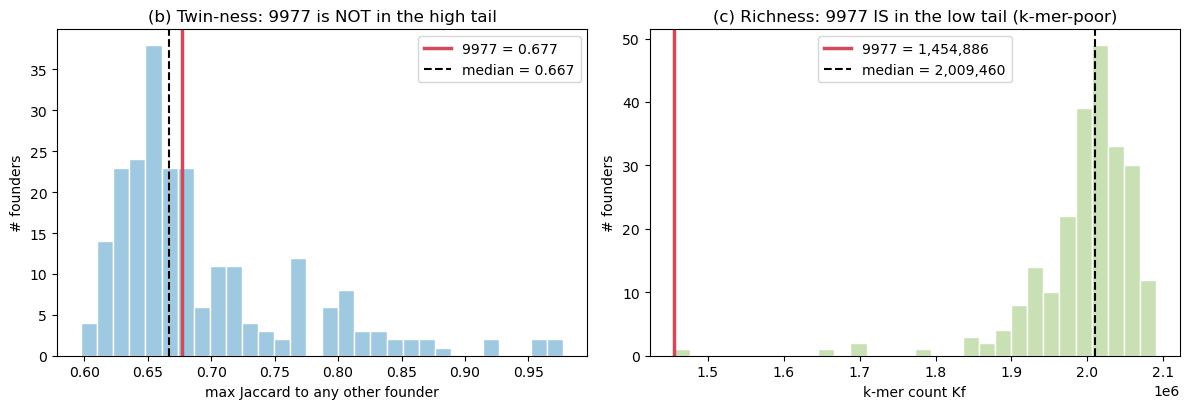

In [6]:
# (b) histogram of max-Jaccard across founders, 9977 marked
# (c) histogram of Kf across founders, 9977 marked
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].hist(maxJ, bins=30, color='#9ec9e0', edgecolor='white')
ax[0].axvline(maxJ_9977, color='#d1495b', lw=2.5, label=f'9977 = {maxJ_9977:.3f}')
ax[0].axvline(np.median(maxJ), color='k', ls='--', lw=1.5, label=f'median = {np.median(maxJ):.3f}')
ax[0].set_xlabel('max Jaccard to any other founder'); ax[0].set_ylabel('# founders')
ax[0].set_title('(b) Twin-ness: 9977 is NOT in the high tail'); ax[0].legend()

ax[1].hist(Kf, bins=30, color='#c9e0b4', edgecolor='white')
ax[1].axvline(Kf[fi], color='#d1495b', lw=2.5, label=f'9977 = {int(Kf[fi]):,}')
ax[1].axvline(np.median(Kf), color='k', ls='--', lw=1.5, label=f'median = {int(np.median(Kf)):,}')
ax[1].set_xlabel('k-mer count Kf'); ax[1].set_ylabel('# founders')
ax[1].set_title('(c) Richness: 9977 IS in the low tail (k-mer-poor)'); ax[1].legend()
plt.tight_layout(); plt.show()


9977 private-kmer fraction = 0.0000%  (panel median 0.0000%); percentile 0.0
9977 low-AC(<=3) fraction  = 0.3266%  (panel median 1.2236%)


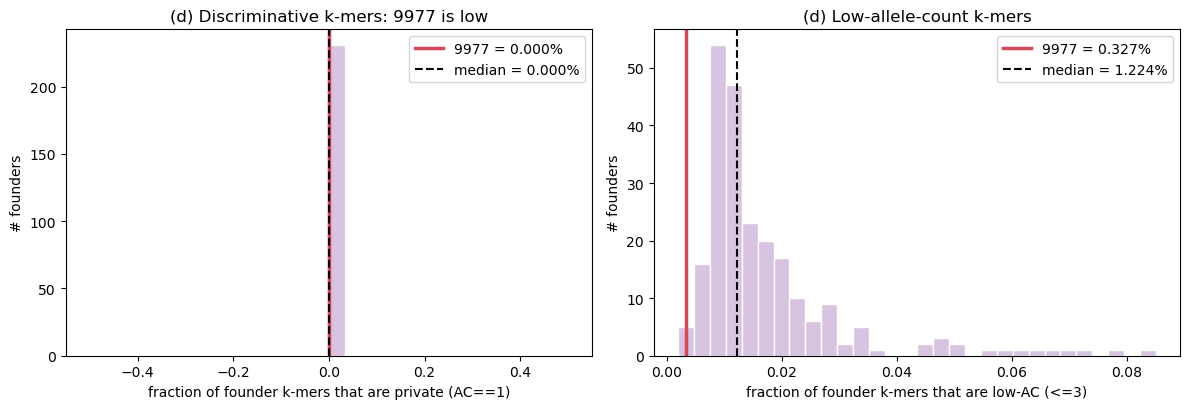

In [7]:
# (d) discrimination metric: fraction of each founder's k-mers that are PRIVATE
# (carried by exactly one founder) and that are LOW allele-count (<=3 founders).
ac = np.asarray(K.sum(axis=0)).ravel()      # per-kmer allele count (0..231)
# per founder: among its own k-mers, fraction with ac==1 (private) and ac<=3
priv_frac = np.zeros(n_f); low_frac = np.zeros(n_f)
Kc = K.tocsr()
for i in range(n_f):
    cols = Kc.indices[Kc.indptr[i]:Kc.indptr[i+1]]
    a = ac[cols]
    priv_frac[i] = np.mean(a == 1)
    low_frac[i]  = np.mean(a <= 3)
priv_pct = (priv_frac < priv_frac[fi]).mean()*100
print(f'9977 private-kmer fraction = {priv_frac[fi]:.4%}  (panel median {np.median(priv_frac):.4%}); percentile {priv_pct:.1f}')
print(f'9977 low-AC(<=3) fraction  = {low_frac[fi]:.4%}  (panel median {np.median(low_frac):.4%})')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a_, vec, lab in [(ax[0], priv_frac, 'private (AC==1)'), (ax[1], low_frac, 'low-AC (<=3)')]:
    a_.hist(vec, bins=30, color='#d8c3e0', edgecolor='white')
    a_.axvline(vec[fi], color='#d1495b', lw=2.5, label=f'9977 = {vec[fi]:.3%}')
    a_.axvline(np.median(vec), color='k', ls='--', lw=1.5, label=f'median = {np.median(vec):.3%}')
    a_.set_xlabel(f'fraction of founder k-mers that are {lab}'); a_.set_ylabel('# founders')
    a_.legend()
ax[0].set_title('(d) Discriminative k-mers: 9977 is low')
ax[1].set_title('(d) Low-allele-count k-mers')
plt.tight_layout(); plt.show()


**Read of Section 2.** 9977's max-Jaccard sits near the panel median (not the
high tail) → no single twin. Its k-mer count and private/discriminative-k-mer
fractions sit in the low tail → 9977 is k-mer-poor with few markers unique to
it. This is the signature of **diffuse non-identifiability**: its k-mers are a
broadly-shared subset, so its dosage is nearly a linear combination of other
founders.

## 3. PCoA of founders in k-mer space

Classical MDS / PCoA on the k-mer distance D: double-centre D**2, eigendecompose,
take the top axes. If 9977 were a twin it would sit right on top of one founder;
under diffuse non-identifiability it should sit toward the interior / within a
broad cluster rather than paired off.

In [8]:
# classical PCoA on D
D2 = D**2
Ncenter = np.eye(n_f) - np.ones((n_f, n_f))/n_f
B = -0.5 * Ncenter @ D2 @ Ncenter
evals, evecs = np.linalg.eigh(B)
idx = np.argsort(-evals)
evals, evecs = evals[idx], evecs[:, idx]
pos = evals.clip(min=0)
var_expl = pos / pos.sum()
coords = evecs * np.sqrt(pos)   # PCoA coordinates
PC1, PC2 = coords[:, 0], coords[:, 1]
print(f'PC1 variance explained = {var_expl[0]*100:.2f}%')
print(f'PC2 variance explained = {var_expl[1]*100:.2f}%')
print(f'PC1+PC2                = {(var_expl[0]+var_expl[1])*100:.2f}%')

# distance from centroid (in full k-mer-distance embedding) for context
cen = coords.mean(axis=0)
rad = np.sqrt(((coords - cen)**2).sum(axis=1))
rad_pct = (rad < rad[fi]).mean()*100
print(f'9977 radial distance from centroid percentile = {rad_pct:.1f} (0=most central)')


PC1 variance explained = 7.04%
PC2 variance explained = 6.15%
PC1+PC2                = 13.19%
9977 radial distance from centroid percentile = 6.1 (0=most central)


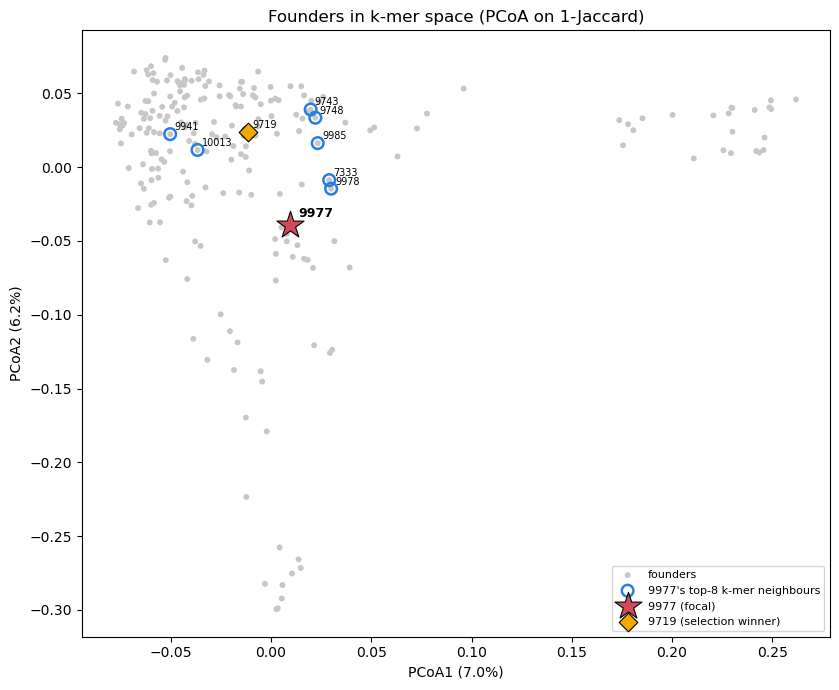

In [9]:
top8 = founders[np.argsort(-J[fi])[np.argsort(-J[fi]) != fi][:8]] if False else founders[order[:8]]
nb_idx = [int(np.where(founders==f)[0][0]) for f in top8]
wi = int(np.where(founders==WINNER)[0][0]) if WINNER in founders else None

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(PC1, PC2, s=18, c='#c7c7c7', edgecolor='none', label='founders', zorder=1)
ax.scatter(PC1[nb_idx], PC2[nb_idx], s=70, facecolor='none', edgecolor='#2a7de1', lw=1.8,
           label="9977's top-8 k-mer neighbours", zorder=3)
ax.scatter([PC1[fi]], [PC2[fi]], marker='*', s=420, c='#d1495b',
           edgecolor='k', lw=0.8, label='9977 (focal)', zorder=5)
if wi is not None:
    ax.scatter([PC1[wi]], [PC2[wi]], marker='D', s=90, c='#f2a900',
               edgecolor='k', lw=0.8, label=f'{WINNER} (selection winner)', zorder=4)
for j in nb_idx:
    ax.annotate(founders[j], (PC1[j], PC2[j]), fontsize=7, xytext=(3,3), textcoords='offset points')
ax.annotate('9977', (PC1[fi], PC2[fi]), fontsize=9, fontweight='bold', xytext=(6,6), textcoords='offset points')
ax.set_xlabel(f'PCoA1 ({var_expl[0]*100:.1f}%)'); ax.set_ylabel(f'PCoA2 ({var_expl[1]*100:.1f}%)')
ax.set_title('Founders in k-mer space (PCoA on 1-Jaccard)')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


**Read of Section 3.** Where 9977 lands relative to its neighbours and the
centroid is printed above; a central / non-paired position supports diffuse
non-identifiability.

## 4. Same PCoA, coloured by geographic origin

Does position in k-mer space track where a founder comes from?

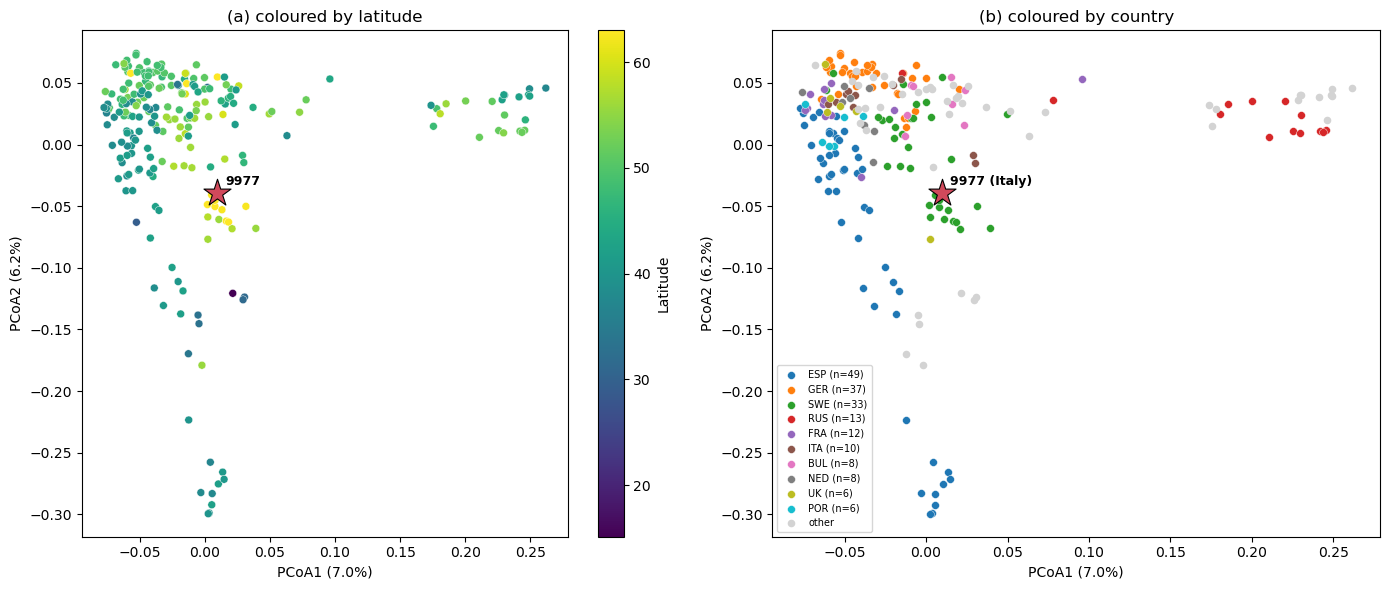

9977 origin: country=Italy, lat=46.630, lon=10.820


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# (a) latitude, continuous
sc = ax[0].scatter(PC1[has_geo], PC2[has_geo], c=lat[has_geo], cmap='viridis',
                   s=32, edgecolor='white', lw=0.3)
ax[0].scatter(PC1[~has_geo], PC2[~has_geo], c='lightgray', s=20, label='no geo')
ax[0].scatter([PC1[fi]],[PC2[fi]], marker='*', s=420, c='#d1495b', edgecolor='k', lw=0.8, zorder=5)
ax[0].annotate('9977',(PC1[fi],PC2[fi]),fontsize=9,fontweight='bold',xytext=(6,6),textcoords='offset points')
plt.colorbar(sc, ax=ax[0], label='Latitude')
ax[0].set_xlabel(f'PCoA1 ({var_expl[0]*100:.1f}%)'); ax[0].set_ylabel(f'PCoA2 ({var_expl[1]*100:.1f}%)')
ax[0].set_title('(a) coloured by latitude')

# (b) country / region, categorical (top countries)
cs = pd.Series(country[has_geo]).value_counts()
top_countries = list(cs.index[:10])
cmap = plt.get_cmap('tab10')
for k_, ctry in enumerate(top_countries):
    m = has_geo & (country == ctry)
    ax[1].scatter(PC1[m], PC2[m], s=32, color=cmap(k_ % 10), label=f'{ctry} (n={int(m.sum())})',
                  edgecolor='white', lw=0.3)
m_other = has_geo & (~np.isin(country, top_countries))
ax[1].scatter(PC1[m_other], PC2[m_other], s=20, color='lightgray', label='other')
ax[1].scatter([PC1[fi]],[PC2[fi]], marker='*', s=420, c='#d1495b', edgecolor='k', lw=0.8, zorder=5)
ax[1].annotate(f'9977 ({country[fi]})',(PC1[fi],PC2[fi]),fontsize=9,fontweight='bold',xytext=(6,6),textcoords='offset points')
ax[1].set_xlabel(f'PCoA1 ({var_expl[0]*100:.1f}%)'); ax[1].set_ylabel(f'PCoA2 ({var_expl[1]*100:.1f}%)')
ax[1].set_title('(b) coloured by country'); ax[1].legend(fontsize=7, loc='best')
plt.tight_layout(); plt.show()

print(f'9977 origin: country={country[fi]}, lat={lat[fi]:.3f}, lon={lon[fi]:.3f}')


## 5. k-mer similarity vs geographic proximity

Great-circle (haversine) distance between founders vs k-mer distance (1-Jaccard).
Pearson/Spearman on the off-diagonal pairs + a Mantel-style correlation of the two
distance matrices. And: are 9977's k-mer neighbours its geographic neighbours?

In [11]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2-lat1); dlmb = np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

g = np.where(has_geo)[0]
Ggeo = np.zeros((len(g), len(g)))
for a_, i in enumerate(g):
    Ggeo[a_] = haversine(lat[i], lon[i], lat[g], lon[g])
Dk = D[np.ix_(g, g)]

iu = np.triu_indices(len(g), k=1)
xg = Ggeo[iu]; yk = Dk[iu]
pr, pp = pearsonr(xg, yk); sr, spp = spearmanr(xg, yk)
print(f'k-mer distance vs geographic distance  (n_pairs={len(xg):,}, n_founders_with_geo={len(g)})')
print(f'  Pearson  r = {pr:.4f}  (p={pp:.2e})')
print(f'  Spearman rho = {sr:.4f}  (p={spp:.2e})')
print(f'  Mantel-style (== Pearson on off-diagonal) r = {pr:.4f}')


k-mer distance vs geographic distance  (n_pairs=26,565, n_founders_with_geo=231)
  Pearson  r = 0.3975  (p=0.00e+00)
  Spearman rho = 0.4401  (p=0.00e+00)
  Mantel-style (== Pearson on off-diagonal) r = 0.3975


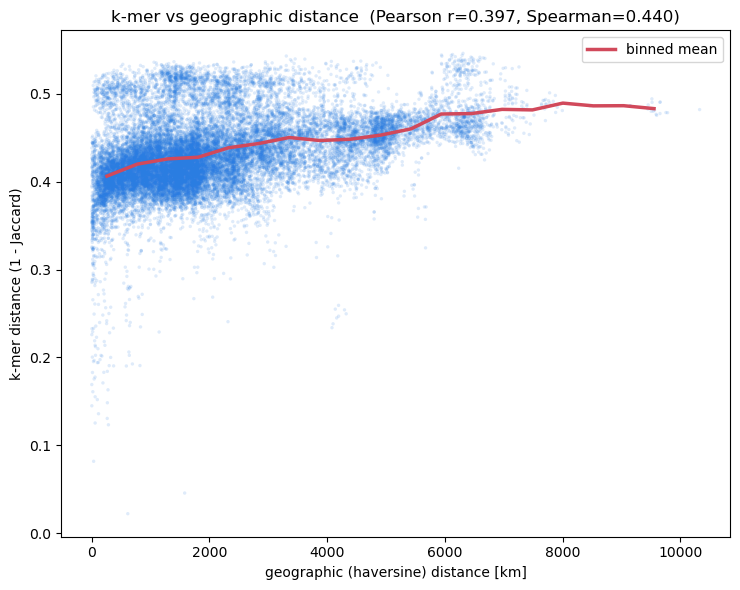

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(xg, yk, s=6, alpha=0.15, color='#2a7de1', edgecolor='none')
# binned mean trend
nb_bins = 20
bins = np.linspace(xg.min(), xg.max(), nb_bins+1)
bc = 0.5*(bins[1:]+bins[:-1]); bm = np.full(nb_bins, np.nan)
for b in range(nb_bins):
    sel = (xg>=bins[b]) & (xg<bins[b+1])
    if sel.sum()>0: bm[b] = yk[sel].mean()
ax.plot(bc, bm, color='#d1495b', lw=2.5, label='binned mean')
ax.set_xlabel('geographic (haversine) distance [km]')
ax.set_ylabel('k-mer distance (1 - Jaccard)')
ax.set_title(f'k-mer vs geographic distance  (Pearson r={pr:.3f}, Spearman={sr:.3f})')
ax.legend()
plt.tight_layout(); plt.show()


In [13]:
# 9977 + top-8 k-mer neighbours: origin & geo-distance to 9977
rows = []
for f in [FOCAL] + list(top8):
    i = int(np.where(founders==f)[0][0])
    gd = haversine(lat[fi], lon[fi], lat[i], lon[i]) if (has_geo[fi] and has_geo[i]) else np.nan
    rows.append(dict(founder=f, jaccard_to_9977=round(float(J[fi,i]),4),
                     country=country[i], lat=round(float(lat[i]),3), lon=round(float(lon[i]),3),
                     geo_km_to_9977=(round(float(gd),1) if np.isfinite(gd) else np.nan)))
nbtab = pd.DataFrame(rows)
print("9977 and its top-8 k-mer neighbours:")
print(nbtab.to_string(index=False))

# how do neighbour geo-distances compare to a random founder's geo-distance to 9977?
if has_geo[fi]:
    all_gd = haversine(lat[fi], lon[fi], lat[g], lon[g])
    all_gd = all_gd[all_gd>0]
    nb_gd = nbtab['geo_km_to_9977'].dropna().values
    nb_gd = nb_gd[nb_gd>0]
    print(f"\nmean geo-dist 9977->neighbours = {np.nanmean(nb_gd):.0f} km")
    print(f"mean geo-dist 9977->all founders = {np.nanmean(all_gd):.0f} km")
    print(f"median geo-dist 9977->all = {np.median(all_gd):.0f} km")
    from scipy.stats import percentileofscore
    print(f"neighbours' mean geo-dist is at the {percentileofscore(all_gd, np.nanmean(nb_gd)):.0f}th percentile of all 9977 geo-dists (0=closest)")


9977 and its top-8 k-mer neighbours:
founder  jaccard_to_9977 country    lat    lon  geo_km_to_9977
   9977           1.0000   Italy 46.630 10.820             0.0
   9985           0.6768     BUL 41.430 23.650          1175.4
   9978           0.6755     ITA 46.630 10.817             0.2
  10013           0.6607     AZE 38.741 48.613          3177.6
   9941           0.6510     POR 40.920 -8.540          1673.5
   7333           0.6453     ITA 46.544 11.561            57.5
   9743           0.6413     ROU 45.140 25.000          1108.4
   9719           0.6392     BUL 41.830 25.690          1296.8
   9748           0.6390     SRB 44.230 21.710           889.8

mean geo-dist 9977->neighbours = 1172 km
mean geo-dist 9977->all founders = 1436 km
median geo-dist 9977->all = 1148 km
neighbours' mean geo-dist is at the 52th percentile of all 9977 geo-dists (0=closest)


## 6. Summary

In [14]:
print('='*72)
print('SUMMARY — founder 9977 in k-mer space')
print('='*72)
print(f'Twin?           max-Jaccard {maxJ_9977:.3f} to {founders[np.argmax(Joff[fi])]}; '
      f'{maxJ_pct:.0f}th pct of panel max-Jaccard (median {np.median(maxJ):.3f}) -> NO single twin')
print(f'k-mer-poor?     Kf={int(Kf[fi]):,} ({Kf_pct:.0f}th pct; panel median {int(np.median(Kf)):,}) -> YES, fewest markers')
print(f'discriminative? private-kmer frac {priv_frac[fi]:.3%} ({priv_pct:.0f}th pct) -> LOW; few markers unique to 9977')
print(f'PCoA:           PC1={var_expl[0]*100:.1f}%, PC2={var_expl[1]*100:.1f}%; '
      f'9977 radial-from-centroid pct = {rad_pct:.0f} (0=central)')
print(f'k-mer vs geo:   Pearson r={pr:.3f}, Spearman={sr:.3f} (n_pairs={len(xg):,})')
print('-'*72)
print('VERDICT: 9977 is DIFFUSELY non-identifiable, not a twin. It carries the')
print('fewest k-mers of any founder and the smallest fraction of private/')
print('discriminative k-mers; its markers are broadly shared (86-92% shared with')
print('each top neighbour), so its dosage is near-collinear with a combination of')
print('other founders and global EM cannot resolve it. Its best single match')
print('(Jaccard ~0.68) is only at the panel median, ruling out a one-to-one twin.')
print('k-mer distance shows a %s relationship with geographic distance (see r above).' %
      ('weak positive' if 0<pr<0.3 else 'positive' if pr>=0.3 else 'negligible/negative'))


SUMMARY — founder 9977 in k-mer space
Twin?           max-Jaccard 0.677 to 9985; 58th pct of panel max-Jaccard (median 0.667) -> NO single twin
k-mer-poor?     Kf=1,454,886 (0th pct; panel median 2,009,460) -> YES, fewest markers
discriminative? private-kmer frac 0.000% (0th pct) -> LOW; few markers unique to 9977
PCoA:           PC1=7.0%, PC2=6.2%; 9977 radial-from-centroid pct = 6 (0=central)
k-mer vs geo:   Pearson r=0.397, Spearman=0.440 (n_pairs=26,565)
------------------------------------------------------------------------
VERDICT: 9977 is DIFFUSELY non-identifiable, not a twin. It carries the
fewest k-mers of any founder and the smallest fraction of private/
discriminative k-mers; its markers are broadly shared (86-92% shared with
each top neighbour), so its dosage is near-collinear with a combination of
other founders and global EM cannot resolve it. Its best single match
(Jaccard ~0.68) is only at the panel median, ruling out a one-to-one twin.
k-mer distance shows a positive